In [1]:
import os
import pandas as pd
import joblib
import config
import numpy as np
from scipy import stats
from itertools import combinations
from sklearn.compose import ColumnTransformer

from preprocessing_utils import *

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, clinical_cols, mrna_cols, mutation_cols = load_and_split_data()
os.makedirs(config.SPLIT_DATA_DIR, exist_ok=True)

# Save all artifacts in the new folder
joblib.dump(X_train, os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
joblib.dump(y_train, os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
joblib.dump(X_val, os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
joblib.dump(y_val, os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
joblib.dump(X_test, os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
joblib.dump(y_test, os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))
joblib.dump(clinical_cols, os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
joblib.dump(mrna_cols, os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
joblib.dump(mutation_cols, os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

on attempt 0
feature: SUBTYPE
  categorical p = 0.21469776142642658
feature: AGE
  numerical (0-1) p = 0.9617342897354705
  numerical (0-2) p = 0.7660187365657699
  numerical (1-2) p = 0.8149282688073907
feature: RACE
  categorical p = 0.29056488014951415
feature: ETHNICITY
  categorical p = 0.3813008880046325
feature: ICD_10
  categorical p = 0.20061056885863307
feature: ICD_O_3_HISTOLOGY
  categorical p = 0.09476642164088667
feature: NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT
  categorical p = 0.5740887958907985
feature: PATH_T_STAGE
feature: PATH_N_STAGE
feature: PATH_M_STAGE
feature: OS_STATUS
  categorical p = 0.526680095722155
feature: DSS_STATUS
  categorical p = 0.3346981543491501
feature: DFS_STATUS
  categorical p = 0.8733485398007202
feature: PFS_STATUS
  categorical p = 0.9800987809120463
feature: CLINICAL_STAGE
  categorical p = 0.2224155020508813
Balanced split achieved after 1 attempts.


['../split_data/mutation_cols.joblib']

In [3]:
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))
clinical_df = X_train[clinical_cols]
mrna_df = X_train[mrna_cols]
mutation_df = X_train[mutation_cols]


In [4]:
print("hello worls")
print(len(mrna_cols))
print(len(mrna_df))
print(clinical_cols)

hello worls
20531
147
['SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS', 'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL', 'SAMPLE_ID', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TYPE', 'GRADE', 'TISSUE_PROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_SOURCE_SITE_CODE', 'TUMOR_TISSUE_SITE', 'ANEUPLOIDY_SCORE', 

In [5]:
uniform_cols = [col for col in clinical_df.columns 
                if clinical_df[col].nunique(dropna=True) <= 1]

print("Fully uniform columns (defined by containing all one value (excluding NaNs): ", uniform_cols)


Fully uniform columns (defined by containing all one value (excluding NaNs):  ['CANCER_TYPE_ACRONYM', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'HISTORY_NEOADJUVANT_TRTYN', 'INFORMED_CONSENT_VERIFIED', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'CANCER_TYPE', 'TUMOR_TISSUE_SITE', 'SAMPLE_TYPE', 'SOMATIC_STATUS']


In [6]:
clinical_df = clinical_df.drop(columns=uniform_cols, errors="ignore")
clinical_df = clinical_df.drop(columns=config.CLINICAL_COLS_TO_REMOVE, errors='ignore')

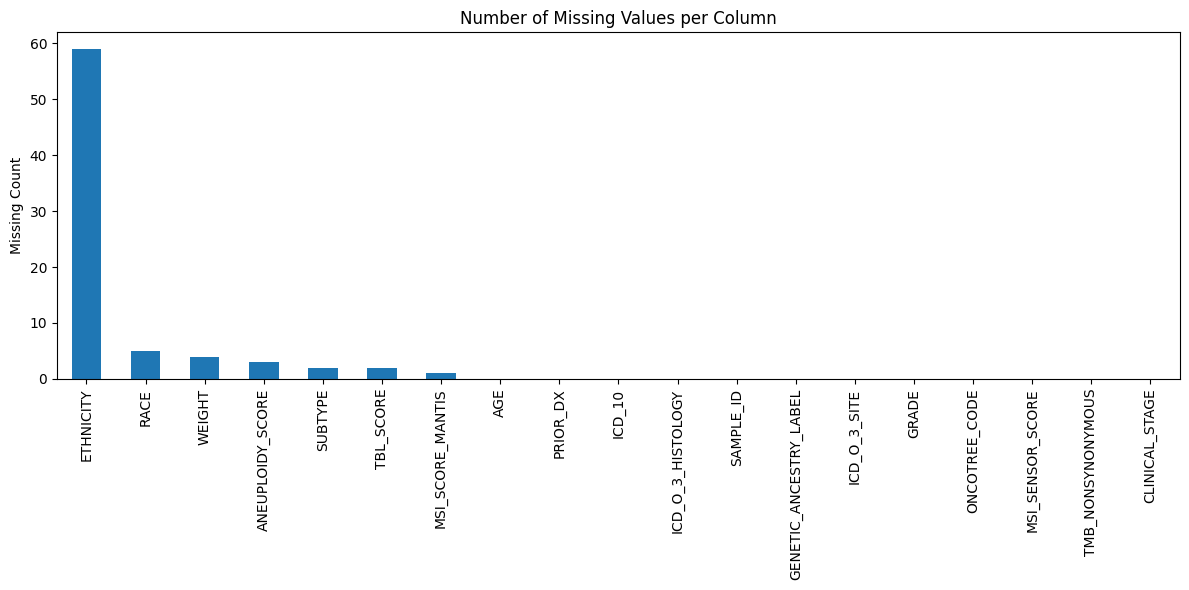

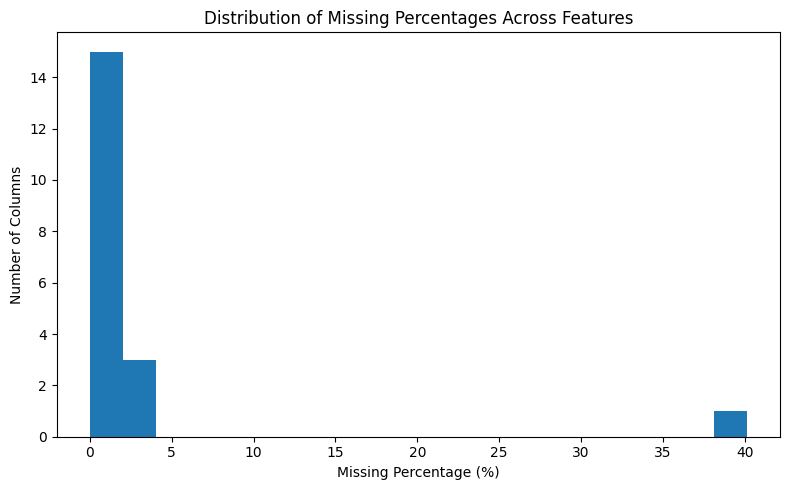

,missing_count,missing_pct
ETHNICITY,59,40.136054
RACE,5,3.401361
WEIGHT,4,2.721088
ANEUPLOIDY_SCORE,3,2.040816
SUBTYPE,2,1.360544
TBL_SCORE,2,1.360544
MSI_SCORE_MANTIS,1,0.680272
AGE,0,0.000000
PRIOR_DX,0,0.000000
ICD_10,0,0.000000


In [7]:
import pandas as pd
import matplotlib.pyplot as plt


# --- Missingness calculations ---
missing_counts = clinical_df.isna().sum().sort_values(ascending=False)
missing_pct = (clinical_df.isna().mean() * 100).sort_values(ascending=False)

# ========== 1. Bar plot of missing counts per column ==========
plt.figure(figsize=(12, 6))
missing_counts.plot(kind='bar')
plt.title("Number of Missing Values per Column")
plt.ylabel("Missing Count")
plt.tight_layout()
plt.show()

# ========== 2. Histogram of missing % across features ==========
plt.figure(figsize=(8, 5))
plt.hist(missing_pct, bins=20)  # *No color specified (as per your style guidelines)
plt.title("Distribution of Missing Percentages Across Features")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Columns")
plt.tight_layout()
plt.show()

# (Optional) Print top missing features to inspect
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_summary

# Really the only column here that is wouldn't otherwise be removed and should is ETHNICITY

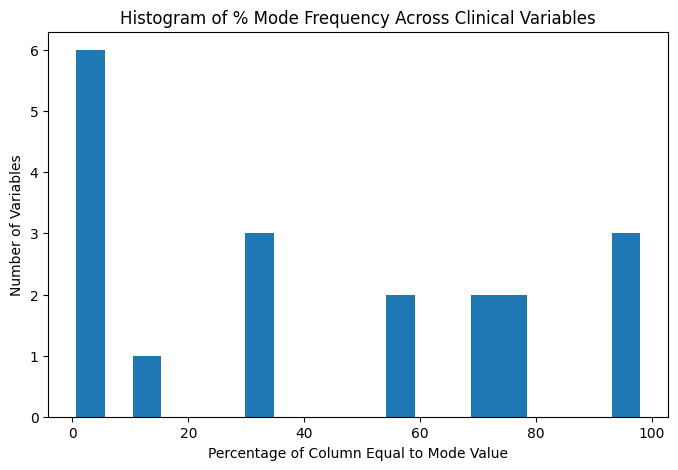

ICD_10                    97.959184
ICD_O_3_SITE              97.959184
PRIOR_DX                  94.557823
ONCOTREE_CODE             75.510204
ICD_O_3_HISTOLOGY         75.510204
GENETIC_ANCESTRY_LABEL    72.789116
RACE                      72.108844
ETHNICITY                 57.142857
GRADE                     55.102041
CLINICAL_STAGE            32.653061
dtype: float64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mode_frequency_histogram(df):
    """
    Computes the % of rows that are equal to the mode value for each column
    and plots a histogram of those percentages.
    """

    mode_freqs = []

    for col in df.columns:
        # Skip columns that can't have a mode frequency (like all NaN or non-hashable)
        try:
            mode_val = df[col].mode(dropna=True)
            if len(mode_val) == 0:
                continue

            mode_val = mode_val.iloc[0]
            freq = (df[col] == mode_val).mean() * 100  # percent
            mode_freqs.append(freq)
        except Exception:
            continue

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(mode_freqs, bins=20)
    plt.xlabel("Percentage of Column Equal to Mode Value")
    plt.ylabel("Number of Variables")
    plt.title("Histogram of % Mode Frequency Across Clinical Variables")
    plt.show()

    return pd.Series(mode_freqs, index=df.columns[:len(mode_freqs)])

mode_freq_series = plot_mode_frequency_histogram(clinical_df)

# Sort descending (most uniform first)
mode_freq_sorted = mode_freq_series.sort_values(ascending=False)

# View top 10 most uniform variables
print(mode_freq_sorted.head(10))


In [9]:
# Combine the column and labels into a temporary dataframe
temp = pd.DataFrame({
    "PRIOR_DX": clinical_df["PRIOR_DX"],
    "Recurrence": y_train
})

# Drop missing values if any
temp = temp.dropna(subset=["PRIOR_DX", "Recurrence"])

# Compute recurrence rates for each group
recurrence_rates = temp.groupby("PRIOR_DX")["Recurrence"].mean() * 100

# Also count number of patients in each group
counts = temp["PRIOR_DX"].value_counts()

print("Counts by PRIOR_DX:")
print(counts)
print("\nRecurrence rates by PRIOR_DX (%):")
print(recurrence_rates)


Counts by PRIOR_DX:
PRIOR_DX
No     139
Yes      8
Name: count, dtype: int64

Recurrence rates by PRIOR_DX (%):
PRIOR_DX
No     35.251799
Yes    50.000000
Name: Recurrence, dtype: float64


### mrna Data Exploration

In [102]:
print("Number of mRNA expression columns:", len(mrna_cols))
all_nan_cols = mrna_df.columns[mrna_df.isna().all()]
print(f"Number of columns that are all NaN: {len(all_nan_cols)}")
mrna_df = mrna_df.drop(columns=all_nan_cols)
uniform_cols = [col for col in mrna_df.columns 
                if mrna_df[col].nunique(dropna=True) <= 1]
print("Total number of uniform columns (only one value excluding NaNs):", len(uniform_cols))
mrna_df = mrna_df.drop(columns=uniform_cols)

# Count columns with no NaNs
no_nan_cols = (mrna_df.isna().sum() == 0).sum()

# Compute percent NaNs for the remaining columns
nan_percent = mrna_df.isna().sum() / mrna_df.shape[0] * 100

# Print value counts
print("Value counts for percent NaN:")
print(nan_percent.value_counts())

mrna_df = mrna_df.loc[:, mrna_df.isna().sum() == 0] # Only Keeping genes with no NaN values

print("Final mRNA expression feature count: ", len(mrna_df.columns))

Number of mRNA expression columns: 20531
Number of columns that are all NaN: 0
Total number of uniform columns (only one value excluding NaNs): 0
Value counts for percent NaN:
0.000000     17507
78.231293     2291
Name: count, dtype: int64
Final mRNA expression feature count:  17507


In [103]:
import matplotlib.pyplot as plt

# Compute variance for each gene/column
variances = mrna_df.var(axis=0)

# Plot histogram
# plt.figure(figsize=(10, 5))
# plt.hist(variances, bins=50, color='skyblue', edgecolor='black')
# plt.xlabel("Variance")
# plt.ylabel("Number of Genes")
# plt.title("Distribution of mRNA Feature Variances")
# plt.grid(True, alpha=0.3)
# plt.show()

variances = mrna_df.var(axis=0)
variances = variances.sort_values()

print(variances.head(20))
print(variances.tail(20))

CEACAM8      0.110874
DEFA5        0.141332
DEFA6        0.235651
REG3A        0.239402
ATOH1        0.274756
CEACAM3      0.302546
HBD          0.350192
CLCA1        0.375313
SNORA3       0.390482
SSX4         0.420218
EVX1         0.427276
CCL23        0.427571
GFI1B        0.429226
TPO          0.431172
KRT12        0.433989
LOC441601    0.474666
RETNLB       0.483052
HESRG        0.494042
AFP          0.501986
MYBPC1       0.508942
dtype: float64
OVOL2           1.880815
LCTL            1.881218
PIP5K1P1        1.894150
DPRXP4          1.905904
FAM21A          1.908988
RPS15AP10       1.919389
KRTAP5-2        1.931466
SNURF           1.934967
C22orf24        1.953396
GP1BA           1.961690
TAS2R4          1.965574
GABARAPL3       1.979399
HCG2P7          1.999713
DNAJB7          2.005328
C11orf42        2.027782
NOMO2           2.052423
EIF3C           2.418948
SYS1-DBNDD2     3.151204
TMED7-TICAM2    3.923996
PPAN-P2RY11     4.104725
dtype: float64


### Mutation Data Exploration

In [119]:
print("Number of Mutation Features: ", len(mutation_df.columns))
# Compute percent NaNs for the remaining columns
nan_percent = mutation_df.isna().sum() / mutation_df.shape[0] * 100

# Print value counts
print("Value counts for percent NaN:")
print(nan_percent.value_counts())


Number of Mutation Features:  19112
Value counts for percent NaN:
0.0    19112
Name: count, dtype: int64


In [9]:
def flag_extreme_mutations(mut_df, threshold=10):
    """
    Identify patient-gene pairs where the mutation count exceeds a threshold.
    
    Parameters
    ----------
    mut_df : pd.DataFrame
        Patient × gene mutation count matrix.
    threshold : int, default=10
        Flag any values greater than this.

    Returns
    -------
    pd.DataFrame
        Long-format DataFrame of patient-gene-count for extreme values.
    """
    # Stack into long format
    stacked = mut_df.stack().reset_index()
    stacked.columns = ["Patient_ID", "Gene", "Count"]
    
    # Filter for extreme values
    flagged = stacked[stacked["Count"] > threshold].sort_values("Count", ascending=False)
    
    return flagged

extremes = flag_extreme_mutations(mutation_df, threshold=0)
print(extremes.head(50))  # show top 20 craziest cases
print(len(extremes))

           Patient_ID         Gene  Count
1221611  TCGA-AX-A0J0      TTN_mut  116.0
2693235  TCGA-EO-A22R      TTN_mut   64.0
1030491  TCGA-AP-A056      TTN_mut   56.0
2387443  TCGA-EO-A22U      TTN_mut   54.0
227787   TCGA-BS-A0UF      TTN_mut   54.0
762923   TCGA-AX-A2HC      TTN_mut   54.0
1489179  TCGA-EO-A3B0      TTN_mut   49.0
514467   TCGA-AX-A06F      TTN_mut   47.0
2769683  TCGA-AX-A05Z      TTN_mut   46.0
2597675  TCGA-B5-A11E      TTN_mut   44.0
2119875  TCGA-FI-A2D5      TTN_mut   44.0
1011379  TCGA-AP-A1DK      TTN_mut   39.0
1966979  TCGA-EO-A22X      TTN_mut   39.0
2712347  TCGA-BS-A0UV      TTN_mut   38.0
552691   TCGA-B5-A3FA      TTN_mut   37.0
2158099  TCGA-DI-A1BU      TTN_mut   35.0
1214237  TCGA-AX-A0J0    MUC16_mut   34.0
2444779  TCGA-AP-A1E0      TTN_mut   33.0
610027   TCGA-B5-A1MX      TTN_mut   29.0
1207889  TCGA-AX-A0J0    CSMD3_mut   28.0
2112501  TCGA-FI-A2D5    MUC16_mut   26.0
2272771  TCGA-EO-A3AY      TTN_mut   26.0
1481805  TCGA-EO-A3B0    MUC16_mut

A lot of the most highly mutated genes are passenger genes such as TTN.

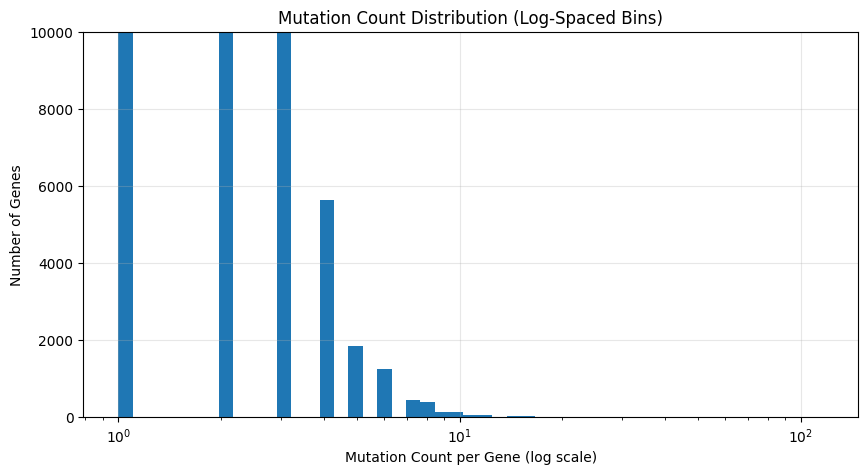

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# extremes = pd.to_numeric(extremes["Count"])
# extremes = extremes.dropna()

data = extremes

# Create log-spaced bins
min_val = max(data.min(), 1)    # avoid log(0)
max_val = data.max()
log_bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)

plt.figure(figsize=(10, 5))
plt.hist(data, bins=log_bins)
plt.xscale("log")
plt.xlabel("Mutation Count per Gene (log scale)")
plt.ylabel("Number of Genes")
plt.title("Mutation Count Distribution (Log-Spaced Bins)")
plt.grid(True, alpha=0.3)
plt.show()


AC007192.6_mut    0
RIMBP3C_mut       0
IER5L_mut         0
A2ML1-AS1_mut     0
AARD_mut          0
                 ..
NDUFS5_mut        2
NDUFS8_mut        2
C6orf123_mut      2
C6orf164_mut      2
VHL_mut           2
Length: 2000, dtype: int64
TP53_mut      62
ARID1A_mut    70
TTN_mut       70
PIK3CA_mut    77
PTEN_mut      97
dtype: int64


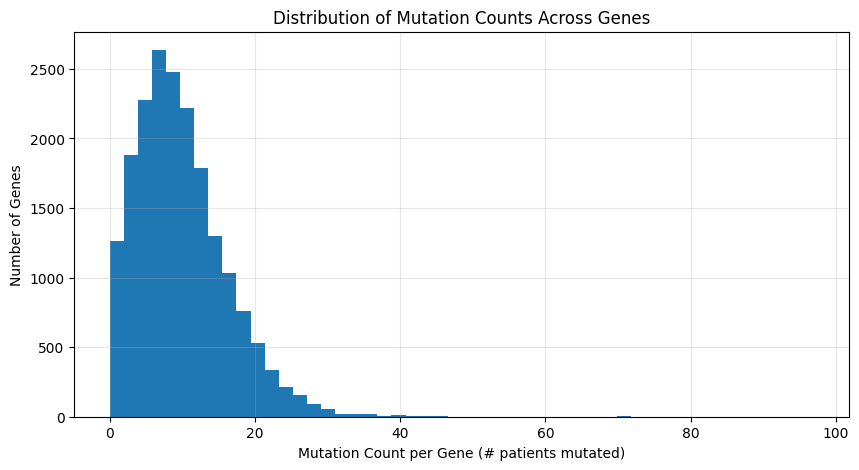

In [51]:
mutation_counts = (mutation_df != 0).sum(axis=0)
mutation_counts = mutation_counts.sort_values()
print(mutation_counts.head(2000))
print(mutation_counts.tail())


plt.figure(figsize=(10, 5))
plt.hist(mutation_counts, bins=50)
plt.xlabel("Mutation Count per Gene (# patients mutated)")
plt.ylabel("Number of Genes")
plt.title("Distribution of Mutation Counts Across Genes")
plt.grid(True, alpha=0.3)
plt.show()


In [38]:
mutation_counts.quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50     9.0
0.80    15.0
0.90    18.0
0.95    21.0
0.99    29.0
dtype: float64

In [39]:
print((mutation_df != 0))

              A1BG_mut  A1BG-AS1_mut  A1CF_mut  A2M_mut  A2ML1_mut  \
TCGA-BS-A0U8     False         False     False    False      False   
TCGA-D1-A15V     False         False     False    False      False   
TCGA-D1-A16D     False         False     False    False      False   
TCGA-BK-A0CC     False         False     False    False      False   
TCGA-AJ-A23M     False         False     False    False      False   
...                ...           ...       ...      ...        ...   
TCGA-BG-A0MA     False         False     False    False      False   
TCGA-BK-A13B     False         False     False    False      False   
TCGA-AX-A05Z      True         False     False     True       True   
TCGA-AP-A1DP     False         False     False    False      False   
TCGA-JU-AAVI     False         False     False    False      False   

              A2ML1-AS1_mut  A2MP1_mut  A3GALT2_mut  A4GALT_mut  A4GNT_mut  \
TCGA-BS-A0U8          False      False        False       False      False   
TCG

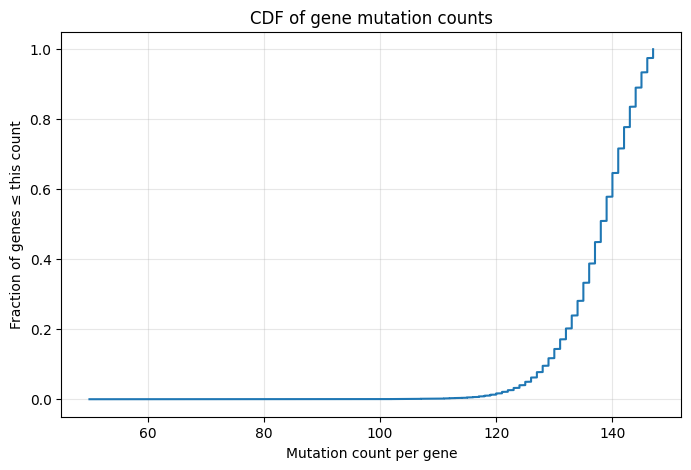

In [41]:
import numpy as np
import matplotlib.pyplot as plt

sorted_counts = np.sort(mutation_counts)
cdf = np.arange(len(sorted_counts)) / len(sorted_counts)

plt.figure(figsize=(8,5))
plt.plot(sorted_counts, cdf)
plt.xlabel("Mutation count per gene")
plt.ylabel("Fraction of genes ≤ this count")
plt.grid(True, alpha=0.3)
plt.title("CDF of gene mutation counts")
plt.show()


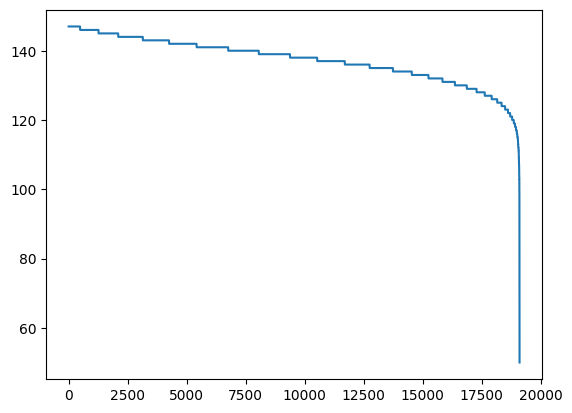

In [42]:
plt.plot(np.sort(mutation_counts)[::-1])

In [1]:
import os
import pandas as pd
import joblib
import config
import numpy as np
from scipy import stats
from itertools import combinations
from sklearn.compose import ColumnTransformer

from preprocessing_utils import *
import config

X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))
clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

# Split modalities
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

clinical_val = X_val[clinical_cols]
mrna_val = X_val[mrna_cols]
mutation_val = X_val[mutation_cols]

clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

print(mrna_train.shape)
print(mutation_train.shape)
print(clinical_train.shape)

# === Initialize and fit each preprocessor on training data ===
clinical_prep = ClinicalPreprocessorWrapper(
    cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
    categorical_cols=config.CATEGORICAL_COLS,
    max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
    uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
)
mrna_prep = MrnaPreprocessorWrapper(
    max_null_frac=config.MAX_NULL_FRAC,
    uniform_thresh=config.UNIFORM_THRESHOLD,
    corr_thresh=config.CORRELATION_THRESHOLD,
    var_thresh=config.VARIANCE_THRESHOLD,
    re_run_pruning=config.RE_RUN_PRUNING,
    literature_genes=config.LITERATURE_GENES,
    correlated_genes_path=config.CORRELATED_GENES_PATH,
    use_stability_selection=config.USE_STABILITY_SELECTION,
    n_boots=config.N_BOOTS_FPR,
    fpr_alpha=config.FPR_ALPHA, #FIXME: put back to config
    stability_threshold=config.STABILITY_THRESHOLD_FPR, # FIXME: put this back to config
    random_state=config.SEED,
)
mutation_prep = MutationPreprocessorWrapper(
    max_null_frac=0.3,
    uniform_thresh=config.MUTATION_UNIFORM_THRESH,
)

# Fit on train
clinical_prep.fit(clinical_train)
mrna_prep.fit(mrna_train, y_train)
mutation_prep.fit(mutation_train)

# Transform train, val, test
clinical_train = clinical_prep.transform(clinical_train)
clinical_val = clinical_prep.transform(clinical_val)
clinical_test = clinical_prep.transform(clinical_test)

mrna_train = mrna_prep.transform(mrna_train)
mrna_val = mrna_prep.transform(mrna_val)
mrna_test = mrna_prep.transform(mrna_test)

mutation_train = mutation_prep.transform(mutation_train)
mutation_val = mutation_prep.transform(mutation_val)
mutation_test = mutation_prep.transform(mutation_test)


(147, 20531)
(147, 19112)
(147, 38)
